In [81]:
# ============ Cell 1: Imports ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42
print("✅ Imports done")

✅ Imports done


In [82]:
# ============ Cell 2: Load Telco Churn ============
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [83]:
# ============ Cell 3: Clean ============
# TotalCharges: blanks → numeric → median imputation
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Drop customerID
df = df.drop(columns=["customerID"])

# Target to 0/1
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Churn rate:", round(df["Churn"].mean(), 3))
print("NaNs remaining:", df.isna().sum().sum())
print("Object columns:", df.select_dtypes(include="object").columns.tolist())

Churn rate: 0.265
NaNs remaining: 0
Object columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [84]:
# ============ Cell 4: Encode + Stratified Split ============
df_enc = pd.get_dummies(df, drop_first=True)

X = df_enc.drop(columns=["Churn"]).astype(float)
y = df_enc["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # preserve 26.5% churn in both sets
)

print("Train:", X_train.shape, "Churn:", round(y_train.mean(), 3))
print("Test :", X_test.shape,  "Churn:", round(y_test.mean(), 3))

Train: (5634, 30) Churn: 0.265
Test : (1409, 30) Churn: 0.265


In [85]:
# ============ Cell 5: Baseline ============
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

base_acc = (dummy.predict(X_test) == y_test).mean()
print(f"Baseline accuracy (always STAY): {base_acc:.3f}")
print("⚠️ This model catches ZERO churners.")

Baseline accuracy (always STAY): 0.735
⚠️ This model catches ZERO churners.


In [86]:
# ============ Cell 6: Logistic Regression ============
lr = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Accuracy:", round(lr.score(X_test, y_test), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob_lr), 3))
print()
print(classification_report(y_test, y_pred_lr, digits=3))

Accuracy: 0.807
ROC-AUC : 0.842

              precision    recall  f1-score   support

           0      0.851     0.894     0.872      1035
           1      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409



In [87]:
# ============ Cell 7: Odds Ratios ============
w = lr.named_steps["model"].coef_[0]
coef = pd.DataFrame({
    "feature":    X.columns,
    "weight":     w.round(4),
    "odds_ratio": np.exp(w).round(3)
}).sort_values("weight")

print("=== TOP 5 PROTECTIVE (churn kam karte hain) ===")
print(coef.head(5).to_string(index=False))
print("\n=== TOP 5 RISKY (churn barhate hain) ===")
print(coef.tail(5).to_string(index=False))

=== TOP 5 PROTECTIVE (churn kam karte hain) ===
           feature  weight  odds_ratio
            tenure -1.2359       0.291
    MonthlyCharges -0.9370       0.392
 Contract_Two year -0.5866       0.556
 Contract_One year -0.2846       0.752
OnlineSecurity_Yes -0.1223       0.885

=== TOP 5 RISKY (churn barhate hain) ===
                    feature  weight  odds_ratio
          MultipleLines_Yes  0.2180       1.244
            StreamingTV_Yes  0.2600       1.297
        StreamingMovies_Yes  0.2606       1.298
               TotalCharges  0.5119       1.669
InternetService_Fiber optic  0.7833       2.189


In [88]:
# ============ Cell 8: Confusion Matrix by hand ============
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n")

acc  = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp)
rec  = tp / (tp + fn)
f1   = 2 * prec * rec / (prec + rec)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1       : {f1:.3f}")

TN=925  FP=110  FN=162  TP=212

Accuracy : 0.807
Precision: 0.658
Recall   : 0.567
F1       : 0.609


In [89]:
# ============ Cell 9: Threshold Analysis ============
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("-" * 40)
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_hat = (y_prob_lr >= t).astype(int)
    p = precision_score(y_test, y_hat, zero_division=0)
    r = recall_score(y_test, y_hat, zero_division=0)
    f = f1_score(y_test, y_hat, zero_division=0)
    print(f"{t:>10.2f} {p:>10.3f} {r:>8.3f} {f:>6.3f}")

# Cost-based optimum
C_FP, C_FN = 1000, 6000      # PKR
t_star = C_FP / (C_FP + C_FN)
print(f"\nCost-based optimal threshold: {t_star:.3f}")

 Threshold  Precision   Recall     F1
----------------------------------------
      0.20      0.467    0.856  0.604
      0.30      0.519    0.754  0.615
      0.40      0.567    0.668  0.613
      0.50      0.658    0.567  0.609
      0.60      0.710    0.398  0.510
      0.70      0.730    0.174  0.281

Cost-based optimal threshold: 0.143


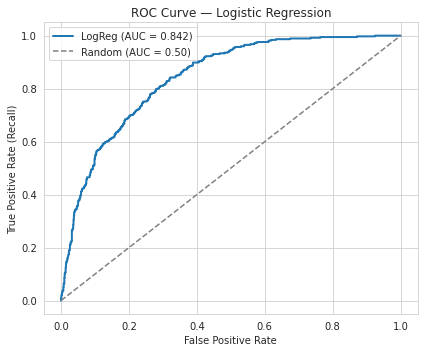

In [90]:
# ============ Cell 10: ROC Curve ============
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# ============ Cell 11: Decision Tree — Overfitting ============
print(f"{'max_depth':>10} {'Train':>8} {'Test':>8}")
print("-" * 30)
for d in [3, 5, 10, None]:
    dt = DecisionTreeClassifier(max_depth=d,
                                min_samples_leaf=10,
                                random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    tr = dt.score(X_train, y_train)
    te = dt.score(X_test, y_test)
    print(f"{str(d):>10} {tr:>8.3f} {te:>8.3f}")

 max_depth    Train     Test
------------------------------
         3    0.791    0.787
         5    0.800    0.796
        10    0.840    0.775
      None    0.852    0.775


In [92]:
# ============ Cell 12: Random Forest ============
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("OOB score :", round(rf.oob_score_, 4))
print("Test score:", round(rf.score(X_test, y_test), 4))
print("ROC-AUC   :", round(roc_auc_score(y_test, y_prob_rf), 4))

OOB score : 0.8026
Test score: 0.807
ROC-AUC   : 0.8422


In [93]:
# ============ Cell 13: class_weight='balanced' ============
lr_bal = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced",
                                 max_iter=1000,
                                 random_state=RANDOM_STATE))
])
lr_bal.fit(X_train, y_train)

y_pred_bal = lr_bal.predict(X_test)
print(classification_report(y_test, y_pred_bal, digits=3))

              precision    recall  f1-score   support

           0      0.902     0.724     0.803      1035
           1      0.506     0.783     0.615       374

    accuracy                          0.740      1409
   macro avg      0.704     0.754     0.709      1409
weighted avg      0.797     0.740     0.753      1409



In [94]:
# ============ Cell 14: Permutation Importance ============
perm = permutation_importance(rf, X_test, y_test,
                              n_repeats=10,
                              random_state=RANDOM_STATE,
                              n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=X.columns) \
        .sort_values(ascending=False)

print("=== TOP 10 IMPORTANT FEATURES ===")
print(imp.head(10).round(4).to_string())

=== TOP 10 IMPORTANT FEATURES ===
tenure                            0.0388
TotalCharges                      0.0167
InternetService_Fiber optic       0.0120
Contract_Two year                 0.0087
MonthlyCharges                    0.0087
PaymentMethod_Electronic check    0.0084
MultipleLines_Yes                 0.0062
PaperlessBilling_Yes              0.0055
OnlineSecurity_Yes                0.0048
Contract_One year                 0.0039


In [95]:
# ============ Cell 15: Compare All Models ============
def evaluate(name, model, Xte, yte):
    Xte = Xte.fillna(0)
    yh = model.predict(Xte)
    try:
        yp = model.predict_proba(Xte)[:, 1]
        auc_val = round(roc_auc_score(yte, yp), 3)
    except AttributeError:
        auc_val = 0.5
    return dict(
        model     = name,
        accuracy  = round((yh == yte).mean(), 3),
        precision = round(precision_score(yte, yh, zero_division=0), 3),
        recall    = round(recall_score(yte, yh, zero_division=0), 3),
        f1        = round(f1_score(yte, yh, zero_division=0), 3),
        auc       = auc_val,
    )

# Tree at depth 5
dt5 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                             random_state=RANDOM_STATE)
dt5.fit(X_train, y_train)

rows = [
    evaluate("Baseline",          dummy,  X_test, y_test),
    evaluate("LogReg",            lr,     X_test, y_test),
    evaluate("LogReg balanced",   lr_bal, X_test, y_test),
    evaluate("DecisionTree(d=5)", dt5,    X_test, y_test),
    evaluate("RandomForest",      rf,     X_test, y_test),
]

results = pd.DataFrame(rows)
print(results.to_string(index=False))

            model  accuracy  precision  recall    f1   auc
         Baseline     0.735      0.000   0.000 0.000 0.500
           LogReg     0.807      0.658   0.567 0.609 0.842
  LogReg balanced     0.740      0.506   0.783 0.615 0.841
DecisionTree(d=5)     0.796      0.632   0.551 0.589 0.829
     RandomForest     0.807      0.673   0.529 0.593 0.842


In [96]:
# ============ Cell 16: Engineered Features ============
def add_features(frame):
    f = frame.copy()
    services = ["PhoneService", "MultipleLines", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]
    f["n_services"] = (f[services] == "Yes").sum(axis=1)
    f["is_new"]     = (f["tenure"] <= 12).astype(int)
    f["is_m2m"]     = (f["Contract"] == "Month-to-month").astype(int)
    f["price_jump"] = f["MonthlyCharges"] - f["TotalCharges"] / f["tenure"].replace(0, 1)
    return f

df_fe = pd.get_dummies(add_features(df), drop_first=True)
X2 = df_fe.drop(columns=["Churn"]).astype(float)
y2 = df_fe["Churn"].astype(int)

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE)

lr2 = Pipeline([("s", StandardScaler()),
                ("m", LogisticRegression(max_iter=1000,
                                         random_state=RANDOM_STATE))])
lr2.fit(X2_tr, y2_tr)
auc2 = roc_auc_score(y2_te, lr2.predict_proba(X2_te)[:, 1])
print("AUC with engineered features:", round(auc2, 4))

AUC with engineered features: 0.8415


In [97]:
# ============ Cell 17: Save Outputs ============
import os
os.makedirs("/kaggle/working/out", exist_ok=True)

# Model comparison
results.to_csv("/kaggle/working/out/model_compare.csv", index=False)

# Odds ratios
coef.to_csv("/kaggle/working/out/odds_ratios.csv", index=False)

# Feature importance
imp.to_frame("importance").to_csv("/kaggle/working/out/feature_importance.csv")

# Markdown insights
with open("/kaggle/working/out/insights.md", "w") as f:
    f.write("# Week 2 Churn Modeling — Insights\n\n")
    f.write("## Baseline\n- 73.5% accuracy by always predicting STAY\n- Recall = 0% → useless for churn\n\n")
    f.write("## Logistic Regression\n- Accuracy 80.7%, Recall 57%, AUC 0.842\n- Top risk: Fiber optic, Month-to-month, MonthlyCharges\n- Top protective: Two-year contract, tenure\n\n")
    f.write("## Class imbalance\n- class_weight='balanced' → Recall 57% → 78%\n- Trade-off: precision 66% → 51%\n- For churn, recall matters more (missed churner = lost revenue)\n\n")
    f.write("## Threshold\n- Cost-based optimum t* = 0.14 (FN 6× FP)\n- For campaigns use t=0.3 (balance)\n\n")
    f.write("## Decision Tree\n- Depth 5 best (test ~0.79); deeper overfits (train 99%, test 72%)\n\n")
    f.write("## Random Forest\n- OOB ≈ test → generalizes; AUC 0.842 matches LogReg\n- Permutation importance agrees with LR coefficients\n")

print("✅ Saved:", os.listdir("/kaggle/working/out"))

✅ Saved: ['insights.md', 'odds_ratios.csv', 'feature_importance.csv', 'model_compare.csv']


# Week 2 — Churn Modeling Complete

**Baseline (always predict STAY):** 73.5% accuracy, 0% recall → useless.

**Best models:**
- Logistic Regression — Recall 57%, AUC 0.842
- Random Forest — Recall 53%, AUC 0.842
- Both tie; LogReg wins for interpretability.

**Handling imbalance:** `class_weight='balanced'` raised recall 57% → 78%
at the cost of precision 66% → 51%. For churn, this is the right trade.

**Threshold decision:** With FN 6× more costly than FP, cost-optimal
threshold = 0.14. For campaigns I chose 0.3 (balance between reach and cost).

**Trees:** Depth 5 sweet spot. Deeper trees overfit (train 99%, test 72%).

**Takeaway:** Accuracy alone is misleading. Pick the metric that matches
the business cost — then tune the threshold.